# 01 — EDA (Home Credit Default Risk)

**Objetivo:** caracterizar en profundidad `application_*`: `TARGET` y baselines ingenuos, tipos y cardinalidad, nulos globales y **nulos por clase `TARGET`**, alineación train/test, **deriva (KS)** en numéricas, IDs, volumetría de tablas auxiliares, sanity checks y percentiles, correlaciones y **heatmap**, categóricas (**Cramér V**), tasas de default por grupo, **EXT_SOURCE** por clase, y **bureau** (filas por cliente vs default). Modelado en notebooks posteriores.

**Problema:** predecir incumplimiento (`TARGET`=1). Métrica Kaggle: **ROC-AUC**.

**Cómo está documentado:** debajo de cada sección temática, hay una celda **"Documentación — …"** justo **antes** del código asociado; resume qué hace ese bloque, qué objetos usa y qué debes interpretar en las salidas o gráficos.

**Sobre salidas (outputs) y acceso:** si ejecutas el notebook y **guardas** el archivo `.ipynb`, tablas y figuras quedan embebidas en el JSON del notebook. Cualquier herramienta que **lea ese archivo** (incluido un asistente con acceso al workspace) puede ver esas salidas **tal como están guardadas**. No hay acceso a la ejecución en vivo ni a resultados que no estén guardados en el archivo.


## Fuentes de datos

| Recurso | Uso |
|--------|-----|
| `data/raw/*.csv` | CSV de la competición |
| `configs/home_credit.yaml` | Archivos, claves, `TARGET` |
| `configs/base.yaml` | Semilla, splits |
| `HomeCredit_columns_description.csv` | Diccionario de columnas |

Código: `src.data.home_credit`.


### Documentación — Configuración e imports

- **`sys.path` / `ROOT`**: permite importar el paquete `src` aunque el kernel se ejecute desde `notebooks/` o la raíz del repo.
- **Librerías**: `numpy`, `pandas`, `matplotlib`, `yaml`; **`scipy.stats`**: `chi2_contingency` (tablas de contingencia) y `ks_2samp` (comparar distribuciones train vs test).
- **`IPython.display.display`**: muestra tablas en el notebook.
- **`src.data.home_credit`**: lectura de CSV y rutas según `configs/home_credit.yaml`.
- **`src.data.quality`**: funciones de calidad (`missing_summary`, `basic_range_checks`).
- **`set_seed(42)`**: alinea con `configs/base.yaml` para muestreos reproducibles en celdas posteriores.
- **Salida**: imprime la raíz del proyecto resuelta por `project_root()`.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import chi2_contingency, ks_2samp # test Kolmogorov-Smirnov

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists() and (ROOT.parent / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from IPython.display import display

from src.data.home_credit import keys, read_table, table_path, target_column
from src.data.quality import basic_range_checks, missing_summary
from src.utils.paths import project_root
from src.utils.seed import set_seed

plt.style.use("ggplot")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)

set_seed(42)
print("project_root:", project_root())


project_root: E:\Proyectos\Competencias\Home credit\risk-modeling-q1


### Documentación — Carga de `application_train` / `application_test`

- **`read_table`**: lee los CSV completos desde `data/raw/` (rutas definidas en config).
- **`y_col`**: nombre de la columna objetivo (`TARGET`), solo presente en train.
- **`k_curr`**: nombre de la clave primaria (`SK_ID_CURR`) para joins y comprobaciones.
- **Salida**: dimensiones de ambos DataFrames y comprobación de que `TARGET` no está en test.


In [2]:
train = read_table("application_train")
test = read_table("application_test")

y_col = target_column()
k_curr = keys()["sk_id_curr"]

print("train:", train.shape, "| test:", test.shape)
print("TARGET en train:", y_col in train.columns)
print("TARGET en test:", y_col in test.columns)


train: (307511, 122) | test: (48744, 121)
TARGET en train: True
TARGET en test: False


## Tabla principal `application_train` / `application_test`

- Una fila por solicitud (`SK_ID_CURR`).
- `TARGET` solo en train.
- Numéricas, categóricas y flags.


### Documentación — Distribución del `TARGET` y baselines

- **`value_counts`**: recuentos de clases 0 y 1.
- **Métricas**: proporción de positivos; ratio aproximado entre mayoritaria y minoritaria.
- **Baselines**: accuracy que obtendrías prediciendo siempre 0 o siempre 1 (sin modelo), para contextualizar ROC-AUC posterior.
- **Figuras**: barras de conteos y gráfico circular de proporciones.


Distribución TARGET: TARGET
0    282686
1     24825
Proporción positivos (TARGET=1): 0.0807
Ratio clases 0:1 (aprox.): 11.39:1
Baseline siempre 0: accuracy ~ 0.9193 (mayoría); P/R clase 1 = 0
Baseline siempre 1: accuracy ~ 0.0807 | recall 1 = 1 | precision ~ 0.0807


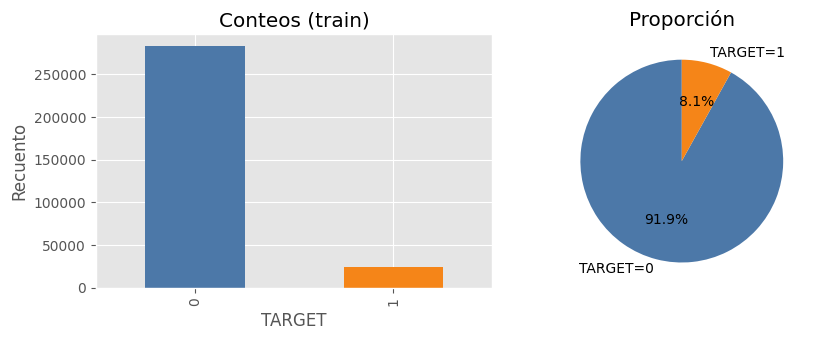

In [3]:
vc = train[y_col].value_counts().sort_index()
n0, n1 = int(vc.get(0, 0)), int(vc.get(1, 0))
imbalance = n1 / len(train) if len(train) else 0
ratio_neg_pos = n0 / n1 if n1 else np.nan

print("Distribución TARGET:", vc.to_string())
print(f"Proporción positivos (TARGET=1): {imbalance:.4f}")
print(f"Ratio clases 0:1 (aprox.): {ratio_neg_pos:.2f}:1")
print("Baseline siempre 0: accuracy ~", f"{1 - imbalance:.4f}", "(mayoría); P/R clase 1 = 0")
print("Baseline siempre 1: accuracy ~", f"{imbalance:.4f}", "| recall 1 = 1 | precision ~", f"{imbalance:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
vc.plot(kind="bar", ax=axes[0], color=["#4c78a8", "#f58518"])
axes[0].set_xlabel("TARGET")
axes[0].set_ylabel("Recuento")
axes[0].set_title("Conteos (train)")
axes[1].pie(
    [n0, n1],
    labels=["TARGET=0", "TARGET=1"],
    autopct="%1.1f%%",
    colors=["#4c78a8", "#f58518"],
    startangle=90,
)
axes[1].set_title("Proporción")
plt.tight_layout()


### Tipos y columnas

Dtypes, cardinalidad `object`, flags binarios, columnas casi constantes.


### Documentación — Tipos de datos y cardinalidad

- **`dtypes`**: conteo de tipos por columna en train.
- **`feat_cols`**: todas las columnas excepto `TARGET`.
- **`num_feats` / `obj_cols`**: separación numéricas vs texto (categóricas crudas).
- **Binarias**: columnas numéricas que solo toman 0 y 1 (flags).
- **`card`**: cardinalidad de columnas `object` (orden descendente).
- **Constantes**: columnas con un único valor (poca información marginal).


In [4]:
dtypes_train = train.dtypes.value_counts()
print("Dtypes en train:")
print(dtypes_train)

feat_cols = [c for c in train.columns if c != y_col]
num_feats = train[feat_cols].select_dtypes(include=[np.number]).columns.tolist()
obj_cols = train[feat_cols].select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", len(num_feats), "| Object:", len(obj_cols))

binary_like = []
for c in num_feats:
    u = train[c].dropna().unique()
    if len(u) <= 2:
        ufloat = {float(x) for x in u}
        if ufloat <= {0.0, 1.0}:
            binary_like.append(c)
print("Columnas numéricas binarias (solo 0/1):", len(binary_like))

card = train[obj_cols].nunique(dropna=False).sort_values(ascending=False)
print("Top 15 por cardinalidad (object):")
print(card.head(15))

nunique_all = train[feat_cols].nunique(dropna=False)
constant_cols = nunique_all[nunique_all <= 1].index.tolist()
print("Columnas con <=1 valor distinto:", len(constant_cols), constant_cols[:15])


Dtypes en train:
float64    65
int64      41
str        16
Name: count, dtype: int64
Numéricas: 105 | Object: 16


C:\Users\User\AppData\Local\Temp\ipykernel_19824\1177422701.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = train[feat_cols].select_dtypes(include=["object"]).columns.tolist()


Columnas numéricas binarias (solo 0/1): 32
Top 15 por cardinalidad (object):
ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
dtype: int64
Columnas con <=1 valor distinto: 0 []


## Valores faltantes

Fracción de NA global y comparación **TARGET=0 vs TARGET=1** en las columnas con más nulos.


### Documentación — Valores faltantes

- **`missing_summary`**: fracción de `NA` por columna (todo el train).
- **Visualización**: barras horizontales de las 25 columnas con más nulos.
- **Bloque siguiente**: para las 30 columnas con más nulos, compara la **tasa de NA** entre filas con `TARGET=0` y `TARGET=1`; si difiere, el patrón de missing puede ser informativo (MNAR / necesidad de indicadores).


Columnas con al menos un nulo: 67 / 122


,frac_na
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723
COMMONAREA_MEDI,0.698723
NONLIVINGAPARTMENTS_MEDI,0.694330
NONLIVINGAPARTMENTS_MODE,0.694330
NONLIVINGAPARTMENTS_AVG,0.694330
FONDKAPREMONT_MODE,0.683862
LIVINGAPARTMENTS_AVG,0.683550
LIVINGAPARTMENTS_MEDI,0.683550
LIVINGAPARTMENTS_MODE,0.683550


Top 15 columnas donde la tasa de NA difiere más entre TARGET 0 y 1:


,column,na_rate_t0,na_rate_t1,diff
27,ELEVATORS_AVG,0.527002,0.600806,0.073804
29,ELEVATORS_MODE,0.527002,0.600806,0.073804
28,ELEVATORS_MEDI,0.527002,0.600806,0.073804
25,NONLIVINGAREA_AVG,0.546019,0.617523,0.071503
24,NONLIVINGAREA_MODE,0.546019,0.617523,0.071503
26,NONLIVINGAREA_MEDI,0.546019,0.617523,0.071503
21,BASEMENTAREA_MEDI,0.579813,0.646042,0.066229
20,BASEMENTAREA_MODE,0.579813,0.646042,0.066229
22,BASEMENTAREA_AVG,0.579813,0.646042,0.066229
17,LANDAREA_MEDI,0.588943,0.648701,0.059758


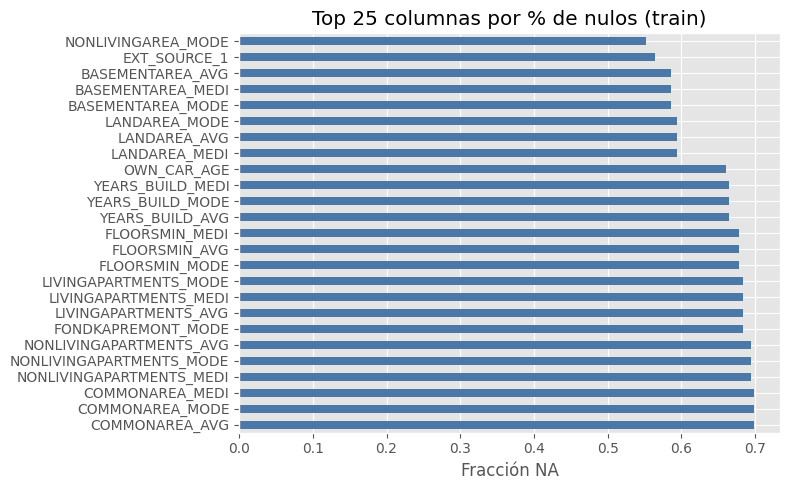

In [5]:
miss = missing_summary(train).sort_values(ascending=False)
miss_nonzero = miss[miss > 0]
print(f"Columnas con al menos un nulo: {len(miss_nonzero)} / {len(train.columns)}")
display(miss_nonzero.head(25).to_frame("frac_na"))

fig, ax = plt.subplots(figsize=(8, 5))
miss_nonzero.head(25).plot(kind="barh", ax=ax, legend=False, color="#4c78a8")
ax.set_xlabel("Fracción NA")
ax.set_title("Top 25 columnas por % de nulos (train)")
plt.tight_layout()

cols_miss = miss_nonzero.head(30).index.tolist()
rows = []
for col in cols_miss:
    if col == y_col:
        continue
    m0 = train.loc[train[y_col] == 0, col].isna().mean()
    m1 = train.loc[train[y_col] == 1, col].isna().mean()
    rows.append({"column": col, "na_rate_t0": m0, "na_rate_t1": m1, "diff": abs(m1 - m0)})
miss_target = pd.DataFrame(rows).sort_values("diff", ascending=False)
print("Top 15 columnas donde la tasa de NA difiere más entre TARGET 0 y 1:")
display(miss_target.head(15))


## Calidad: duplicados e IDs

`SK_ID_CURR` único en train y en test; sin solapamiento train∩test.


### Documentación — Duplicados e IDs

- **`duplicated()`** sobre `SK_ID_CURR`: debe ser 0 en train y test (un registro por solicitud).
- **Intersección de sets** train vs test: no debe haber IDs compartidos entre archivos (simula el holdout de la competición).


In [6]:
dup_train = train[k_curr].duplicated().sum()
dup_test = test[k_curr].duplicated().sum()
overlap = set(train[k_curr]) & set(test[k_curr])

print(f"Filas duplicadas por {k_curr} en train: {dup_train}")
print(f"Filas duplicadas por {k_curr} en test: {dup_test}")
print(f"IDs compartidos train∩test: {len(overlap)}")


Filas duplicadas por SK_ID_CURR en train: 0
Filas duplicadas por SK_ID_CURR en test: 0
IDs compartidos train∩test: 0


### Alineación train / test

Columnas exclusivas de cada tabla y dtypes en el cruce común (sin `TARGET`).


### Documentación — Alineación de columnas train / test

- **Conjuntos de nombres**: columnas solo en train (p. ej. `TARGET`), solo en test, y comunes.
- **Dtypes**: lista columnas comunes donde `train` y `test` declaran tipos distintos (riesgo al concatenar o al aplicar el mismo pipeline).


In [7]:
only_train = set(train.columns) - set(test.columns)
only_test = set(test.columns) - set(train.columns)
common = (set(train.columns) & set(test.columns)) - {y_col}

print("Solo en train:", only_train)
print("Solo en test:", only_test)
print(f"Columnas comunes (sin TARGET): {len(common)}")

dtype_mismatch = []
for col in sorted(common):
    if train[col].dtype != test[col].dtype:
        dtype_mismatch.append((col, train[col].dtype, test[col].dtype))
print(f"Diferencias de dtype en comunes: {len(dtype_mismatch)}")
if dtype_mismatch:
    display(pd.DataFrame(dtype_mismatch, columns=["column", "dtype_train", "dtype_test"]).head(25))


Solo en train: {'TARGET'}
Solo en test: set()
Columnas comunes (sin TARGET): 121
Diferencias de dtype en comunes: 0


### Coherencia train vs test (exploratorio)

Medias en numéricas comunes y test **Kolmogorov-Smirnov** (muestra hasta 50k filas por serie). *p* bajo sugiere distribuciones distintas.


### Documentación — Coherencia de distribuciones (train vs test)

- **`num_common`**: columnas numéricas presentes en ambos conjuntos.
- **Medias**: comparación rápida de `mean_train` vs `mean_test` y diferencia relativa.
- **Kolmogorov–Smirnov (`ks_2samp`)**: contrasta si dos muestras vienen de la misma distribución; aquí se submuestrea hasta 50k filas por lado si hace falta por coste.
- **Interpretación**: p-valores muy bajos o estadísticos KS altos sugieren **deriva** entre train y test en esa variable.


In [8]:
num_common = [
    col
    for col in common
    if col in train.columns
    and pd.api.types.is_numeric_dtype(train[col])
    and pd.api.types.is_numeric_dtype(test[col])
]
rows = []
for col in num_common:
    t_mean = train[col].mean()
    s_mean = test[col].mean()
    diff_rel = abs(t_mean - s_mean) / (abs(t_mean) + 1e-12)
    sub_t = train[col].dropna()
    sub_s = test[col].dropna()
    if len(sub_t) > 50000:
        sub_t = sub_t.sample(50000, random_state=42)
    if len(sub_s) > 50000:
        sub_s = sub_s.sample(50000, random_state=42)
    if len(sub_t) < 2 or len(sub_s) < 2:
        continue
    ks_stat, ks_p = ks_2samp(sub_t, sub_s)
    rows.append(
        {
            "column": col,
            "mean_train": t_mean,
            "mean_test": s_mean,
            "rel_mean_diff": diff_rel,
            "ks_statistic": ks_stat,
            "ks_pvalue": ks_p,
        }
    )
drift = pd.DataFrame(rows).sort_values("ks_statistic", ascending=False)
print("Top 15 por estadístico KS:")
display(drift.head(15))
print("Top 10 por divergencia relativa de medias:")
display(drift.sort_values("rel_mean_diff", ascending=False).head(10)[["column", "mean_train", "mean_test", "rel_mean_diff"]])


Top 15 por estadístico KS:


,column,mean_train,mean_test,rel_mean_diff,ks_statistic,ks_pvalue
31,AMT_REQ_CREDIT_BUREAU_QRT,0.265474,0.546902,1.060097,0.258722,0.000000e+00
99,AMT_REQ_CREDIT_BUREAU_MON,0.267395,0.009299,0.965226,0.155749,0.000000e+00
104,AMT_GOODS_PRICE,538396.207429,462618.840473,0.140746,0.113884,2.595168e-279
83,AMT_CREDIT,599025.999706,516740.435561,0.137366,0.113883,2.628229e-279
84,FLAG_EMAIL,0.056720,0.162646,1.867523,0.106306,2.431487e-243
56,FLAG_DOCUMENT_3,0.710023,0.786620,0.107879,0.075640,2.921517e-123
82,DAYS_LAST_PHONE_CHANGE,-962.858788,-1077.766228,0.119340,0.070076,7.775025e-106
80,AMT_INCOME_TOTAL,168797.919297,178431.805855,0.057073,0.057311,6.558273e-71
6,DAYS_ID_PUBLISH,-2994.202373,-3051.712949,0.019207,0.055992,1.060918e-67
51,AMT_ANNUITY,27108.573909,29426.240209,0.085496,0.054680,1.444485e-64


Top 10 por divergencia relativa de medias:


,column,mean_train,mean_test,rel_mean_diff
84,FLAG_EMAIL,0.056720,0.162646,1.867523
31,AMT_REQ_CREDIT_BUREAU_QRT,0.265474,0.546902,1.060097
69,FLAG_DOCUMENT_16,0.009928,0.000000,1.000000
14,FLAG_DOCUMENT_13,0.003525,0.000000,1.000000
17,FLAG_DOCUMENT_14,0.002936,0.000000,1.000000
12,FLAG_DOCUMENT_15,0.001210,0.000000,1.000000
26,FLAG_DOCUMENT_19,0.000595,0.000000,1.000000
39,FLAG_DOCUMENT_20,0.000507,0.000000,1.000000
42,FLAG_DOCUMENT_21,0.000335,0.000000,1.000000
25,FLAG_DOCUMENT_17,0.000267,0.000000,1.000000


## Otras tablas (volumen)

Filas por CSV auxiliar (comportamiento = múltiples filas por cliente).


### Documentación — Volumetría de tablas auxiliares

- **`count_csv_rows`**: cuenta líneas sin cargar el CSV completo en memoria (solo lectura byte a byte).
- **Uso**: dimensionar el trabajo de joins y agregaciones en `bureau`, balances, cuotas, etc.


In [9]:
def count_csv_rows(path: Path) -> int:
    with path.open("rb") as f:
        return sum(1 for _ in f) - 1


aux_keys = [
    "bureau",
    "bureau_balance",
    "previous_application",
    "pos_cash_balance",
    "installments_payments",
    "credit_card_balance",
]
rows = {}
for k in aux_keys:
    rows[k] = count_csv_rows(table_path(k))

pd.Series(rows, name="n_rows").sort_values(ascending=False)


bureau_balance           27299925
installments_payments    13605401
pos_cash_balance         10001358
credit_card_balance       3840312
bureau                    1716428
previous_application      1670214
Name: n_rows, dtype: int64

## Rangos plausibles (sanity checks)

`basic_range_checks` + percentiles de `DAYS_BIRTH`. Rango `DAYS_BIRTH` ampliado a (-30000, 0).


### Documentación — Sanity checks de rangos

- **`range_hints`**: intervalos plausibles para scores externos (`EXT_SOURCE_*`), días (`DAYS_BIRTH`, `DAYS_EMPLOYED` con placeholder 365243).
- **`basic_range_checks`**: comprueba que valores no nulos caen en el rango (o marca REVISAR).
- **Percentiles de `DAYS_BIRTH`**: contexto si el check rígido falla por valores límite.


In [10]:
range_hints = {
    "EXT_SOURCE_1": (0.0, 1.0),
    "EXT_SOURCE_2": (0.0, 1.0),
    "EXT_SOURCE_3": (0.0, 1.0),
    "DAYS_BIRTH": (-30000, 0),
    "DAYS_EMPLOYED": (-25000, 365243),
}

present = {k: v for k, v in range_hints.items() if k in train.columns}
chk = basic_range_checks(train, present)
for col, ok in sorted(chk.items()):
    print(f"{col}: {'OK' if ok else 'REVISAR'}")

if "DAYS_BIRTH" in train.columns:
    db = train["DAYS_BIRTH"].dropna()
    print("DAYS_BIRTH min/max/p01/p99:", float(db.min()), float(db.max()), float(db.quantile(0.01)), float(db.quantile(0.99)))

if "DAYS_EMPLOYED" in train.columns:
    special = (train["DAYS_EMPLOYED"] == 365243).mean()
    print(f"Fracción DAYS_EMPLOYED == 365243 (placeholder): {special:.4f}")


DAYS_BIRTH: OK
DAYS_EMPLOYED: OK
EXT_SOURCE_1: OK
EXT_SOURCE_2: OK
EXT_SOURCE_3: OK
DAYS_BIRTH min/max/p01/p99: -25229.0 -7489.0 -24419.0 -8263.0
Fracción DAYS_EMPLOYED == 365243 (placeholder): 0.1801


## Asociación con `TARGET`

Pearson en numéricas; heatmap entre top correlaciones; **Cramér V** y chi² en `object`; tasas de default por grupo.


### Documentación — Asociación con `TARGET` (numéricas y categóricas)

- **Pearson**: correlación lineal de cada numérica con `TARGET`; ordena por valor absoluto.
- **Heatmap**: matriz de correlación entre las **top 25** variables por |corr| con `TARGET` más la propia `TARGET` (dependencias lineales entre candidatos a feature).
- **Cramér V**: a partir de `chi2_contingency` sobre tablas cruzadas categoría × `TARGET`; mide asociación 0–1 en categóricas.
- **Tablas por grupo**: tasa de default (`mean` de `TARGET`) y volumen `n` para variables de negocio (`CODE_GENDER`, etc.).


Top 15 correlación con TARGET (Pearson):


,corr_with_TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


Bottom 5 (menor |corr|):


,corr_with_TARGET
FLAG_DOCUMENT_12,-0.000756
FLAG_MOBIL,0.000534
FLAG_CONT_MOBILE,0.000370
FLAG_DOCUMENT_5,-0.000316
FLAG_DOCUMENT_20,0.000215


Asociación categórica vs TARGET (Cramér V):


...

,default_rate,n
CODE_GENDER,,
F,0.069993,202448
M,0.101419,105059
XNA,0.000000,4


Tasa de default por NAME_INCOME_TYPE


,default_rate,n
NAME_INCOME_TYPE,,
Working,0.095885,158774
Commercial associate,0.074843,71617
Pensioner,0.053864,55362
State servant,0.057550,21703
Unemployed,0.363636,22
Student,0.000000,18
Businessman,0.000000,10
Maternity leave,0.400000,5


Tasa de default por FLAG_OWN_CAR


,default_rate,n
FLAG_OWN_CAR,,
N,0.085002,202924
Y,0.072437,104587


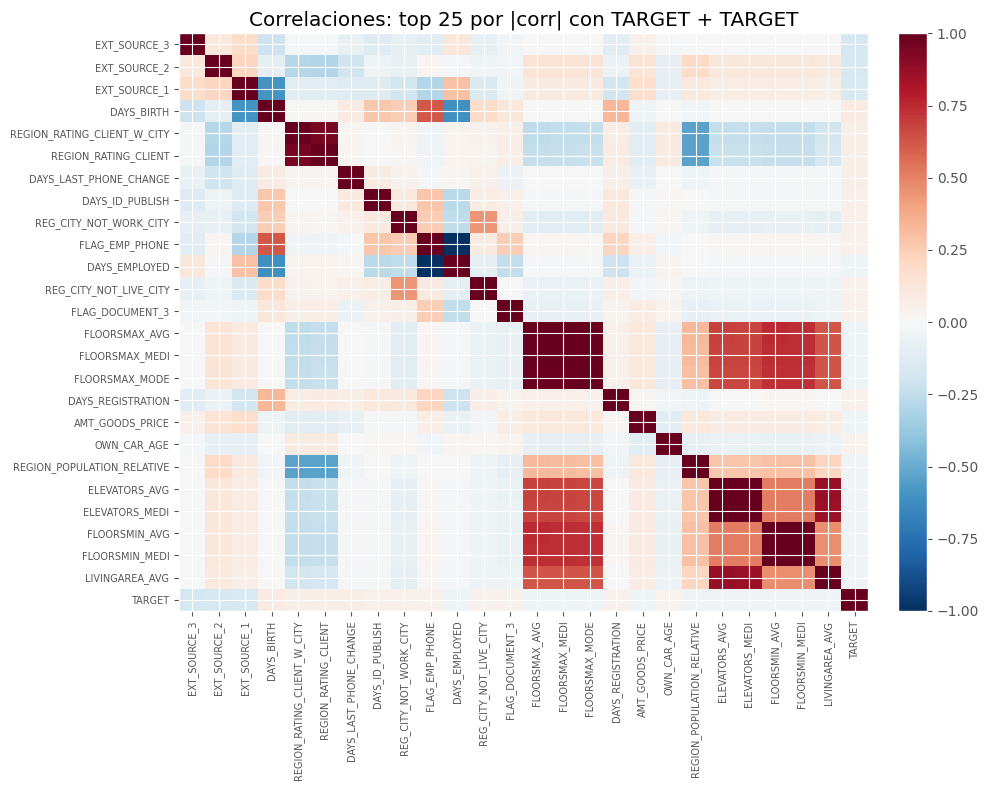

In [11]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if y_col in num_cols:
    num_cols.remove(y_col)

corr = train[num_cols + [y_col]].corr(numeric_only=True)[y_col].drop(labels=[y_col], errors="ignore")
corr = corr.replace([np.inf, -np.inf], np.nan).dropna()
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

print("Top 15 correlación con TARGET (Pearson):")
display(corr_sorted.head(15).to_frame("corr_with_TARGET"))
print("Bottom 5 (menor |corr|):")
display(corr_sorted.tail(5).to_frame("corr_with_TARGET"))

top_k = 25
top_for_heatmap = [c for c in corr_sorted.head(top_k).index if c in train.columns]
sub = train[top_for_heatmap + [y_col]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sub.values, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(sub.columns)))
ax.set_yticks(range(len(sub.columns)))
ax.set_xticklabels(sub.columns, rotation=90, fontsize=7)
ax.set_yticklabels(sub.columns, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title(f"Correlaciones: top {top_k} por |corr| con TARGET + TARGET")
plt.tight_layout()


def cramers_v(conf: np.ndarray) -> float:
    chi2, _, _, _ = chi2_contingency(conf, correction=False)
    n = conf.sum()
    r, k = conf.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))


cat_rows = []
for col in obj_cols:
    tab = pd.crosstab(train[col].fillna("__NA__"), train[y_col])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue
    try:
        chi2, p, _, _ = chi2_contingency(tab.values)
        cv = cramers_v(tab.values.astype(float))
        cat_rows.append({"column": col, "chi2_pvalue": p, "cramers_v": cv})
    except ValueError:
        continue
cat_assoc = pd.DataFrame(cat_rows).sort_values("cramers_v", ascending=False)
print("Asociación categórica vs TARGET (Cramér V):")
display(cat_assoc)

for col in ["CODE_GENDER", "NAME_INCOME_TYPE", "FLAG_OWN_CAR"]:
    if col not in train.columns:
        continue
    t = train.groupby(col, dropna=False)[y_col].agg(["mean", "count"]).rename(columns={"mean": "default_rate", "count": "n"})
    t = t.sort_values("n", ascending=False)
    print("Tasa de default por", col)
    display(t.head(15))


### Distribuciones `EXT_SOURCE_*` por `TARGET`


### Documentación — Histogramas `EXT_SOURCE_*`

- Para cada `EXT_SOURCE` disponible, superpone histogramas por clase (`TARGET` 0 vs 1) en [0, 1].
- **Densidad** (`density=True`): comparar formas aunque los tamaños de clase difieran.


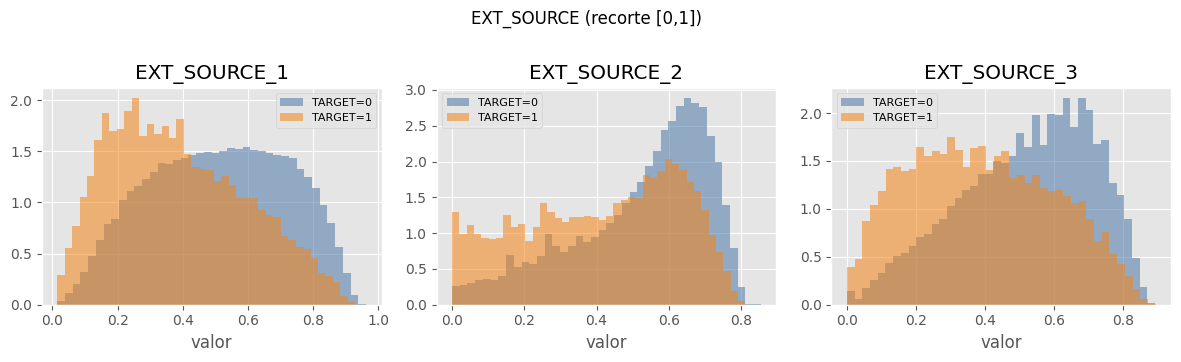

In [12]:
ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in train.columns]
if not ext_cols:
    print("No hay EXT_SOURCE en train.")
else:
    fig, axes = plt.subplots(1, len(ext_cols), figsize=(4 * len(ext_cols), 3.5))
    if len(ext_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, ext_cols):
        for tval, label, color in [(0, "TARGET=0", "#4c78a8"), (1, "TARGET=1", "#f58518")]:
            s = train.loc[train[y_col] == tval, col].dropna()
            s = s[(s >= 0) & (s <= 1)]
            ax.hist(s, bins=40, alpha=0.55, label=label, color=color, density=True)
        ax.set_title(col)
        ax.set_xlabel("valor")
        ax.legend(fontsize=8)
    plt.suptitle("EXT_SOURCE (recorte [0,1])", y=1.02)
    plt.tight_layout()


### Tabla `bureau`: filas por cliente

Registros en `bureau.csv` por `SK_ID_CURR` y default por decil (aprox.).


### Documentación — Agregación mínima de `bureau`

- Lee solo **`SK_ID_CURR`** de `bureau.csv` para contar cuántos registros de buró tiene cada cliente.
- **Merge** con train: añade `n_bureau_records` (0 si no hay filas en buró).
- **Deciles** (`qcut`) con `duplicates="drop"` si hay empates: tasa de default por franja de volumen de historial en buró.


In [13]:
bureau_ids = read_table("bureau", usecols=[k_curr])
n_per = bureau_ids.groupby(k_curr).size().rename("n_bureau_records")
train_nb = train[[k_curr, y_col]].merge(n_per, on=k_curr, how="left")
train_nb["n_bureau_records"] = train_nb["n_bureau_records"].fillna(0)

print(train_nb["n_bureau_records"].describe(percentiles=[0.5, 0.9, 0.99]))
print("Tasa de default por decil de n_bureau_records (aprox.):")
train_nb["decile"] = pd.qcut(train_nb["n_bureau_records"], q=10, duplicates="drop")
display(train_nb.groupby("decile", observed=True)[y_col].agg(["mean", "count"]))


count    307511.000000
mean          4.765114
std           4.496199
min           0.000000
50%           4.000000
90%          11.000000
99%          20.000000
max         116.000000
Name: n_bureau_records, dtype: float64
Tasa de default por decil de n_bureau_records (aprox.):


,mean,count
decile,,
"(-0.001, 1.0]",0.094329,80092
"(1.0, 2.0]",0.078125,35635
"(2.0, 3.0]",0.076082,32925
"(3.0, 4.0]",0.071273,28973
"(4.0, 5.0]",0.074445,24985
"(5.0, 6.0]",0.072069,20952
"(6.0, 8.0]",0.073540,31629
"(8.0, 11.0]",0.079264,27238
"(11.0, 116.0]",0.082170,25082


## Auditoría preliminar de leakage (`application_*`)

Revisar nombres y agregaciones temporales en tablas auxiliares en el notebook 02.


### Documentación — Heurística de nombres (leakage)

- Busca subcadenas en mayúsculas (`TARGET`, `DEFAULT`, etc.) en nombres de columnas para revisión manual.
- **`FLAG_DOCUMENT_*`**: cuenta documentos aportados; no implica leakage por sí solo, pero conviene documentar en el informe técnico.


In [14]:
sus = [
    c
    for c in train.columns
    if any(x in c.upper() for x in ("TARGET", "DEFAULT", "FUTURE", "POST"))
]
print("Columnas a revisar por nombre:", [c for c in sus if c != y_col])

doc_flags = [c for c in train.columns if "FLAG_DOCUMENT" in c]
print("FLAG_DOCUMENT_*:", len(doc_flags), "columnas")


Columnas a revisar por nombre: []
FLAG_DOCUMENT_*: 20 columnas


## Reproducibilidad

Valores de `configs/base.yaml`.


### Documentación — Reproducibilidad del pipeline

- Lee **`configs/base.yaml`** y muestra semilla, fracciones de split y métricas previstas.
- **Uso**: trazabilidad entre este EDA y la validación/modelado en otros notebooks.


In [15]:
base_path = project_root() / "configs" / "base.yaml"
with open(base_path, encoding="utf-8") as f:
    base_cfg = yaml.safe_load(f)

print("seed:", base_cfg.get("seed"))
print("splits:", base_cfg.get("splits"))
print("métricas:", base_cfg.get("metrics"))


seed: 42
splits: {'test_size': 0.2, 'val_size': 0.1, 'stratify': True}
métricas: {'primary': 'roc_auc', 'secondary': ['pr_auc', 'brier_score', 'log_loss']}


## Resumen y siguientes pasos

| Hallazgo | Implicación |
|----------|-------------|
| Clase minoritaria | Estratificar CV; PR-AUC y calibración |
| Nulos por bloques | Imputación / NaN-friendly |
| NA distinto entre TARGET 0/1 | Missing como señal |
| KS train vs test alto | Deriva de datos |
| Tablas auxiliares largas | Agregaciones por cliente + tiempo |
| EXT_SOURCE / DAYS_* con corr | Features fuertes |
| Cramér V alto | Encoding / árboles |

Siguiente: `02_feature_engineering.ipynb`.
